In [ ]:
import sys
import os.path as osp
import torch
import pandas as pd
from tqdm import tqdm

sys.path.append("..")
from src.vit.experts import ViTExpert, optional_sidecar  # noqa: E402
from src.hf.experts import HFExpert
from src import merging

# # >>> CONFIG

# datasets = [
#     "Cars",
#     "DTD",
#     "EuroSAT",
#     "GTSRB",
#     "MNIST",
#     "RESISC45",
#     "SUN397",
#     "SVHN",
# ]
# experts_dir = osp.join(
#     "../artifacts/checkpoints", "ViT-B-16", f"group-legacy-fft-8", "experts"
# )
# experts = [
#     ViTExpert(
#         weights_path=osp.join(experts_dir, ds, "finetuned.pt"),
#         covariance_path=optional_sidecar(osp.join(experts_dir, ds), "covariance.pt"),
#     )
#     for ds in datasets
# ]
# base = ViTExpert(weights_path=osp.join(experts_dir, datasets[0], "pretrained.pt"))

# # <<<<


def get_nearest_linear_merge(delta, delta_m):
    """argmin_a ||sum_t a_t delta[t] - delta_m||_F  via the normal equations.

    delta [T,Do,Di] task vectors, delta_m [Do,Di] merged task vector -> a [T].
    rcond is a cutoff on singular values of A, so it is squared for the Gram matrix.
    """
    A = delta.flatten(1).T  # d x T, columns are vec(delta_t)
    b = delta_m.flatten()  # d
    # [TxT] [Txd] [dx1]
    return torch.linalg.pinv(A.T @ A) @ (A.T @ b)


rows = []  # one |cos| per (task, layer, method)
for layer in tqdm(base.get_layers()):
    d_tens = []
    w0 = base.get_layer_params(layer)
    if w0.ndim != 2:
        continue
    for ds, exp in zip(datasets, experts):
        w = exp.get_layer_params(layer)
        d = (w - w0).float()
        d_tens.append(d)

    d_tens = torch.stack(d_tens)
    for merge_method in ["mean", "isoc", "tsv", "actmat"]:
        merge_fn = getattr(merging, "merge_" + merge_method)
        # print(d_tens.shape)
        dm = merge_fn(d_tens)
        alphas = get_nearest_linear_merge(d_tens, dm)
        rows.append(
            {
                "method": merge_method,
                **{f"{datasets[i]}": a.item() for i, a in enumerate(alphas)},
            }
        )
        # print(f"{ds} | {merge_method}: {alphas}")
df = pd.DataFrame(rows)

100%|██████████| 206/206 [02:58<00:00,  1.15it/s]


<Axes: xlabel='method', ylabel='task'>

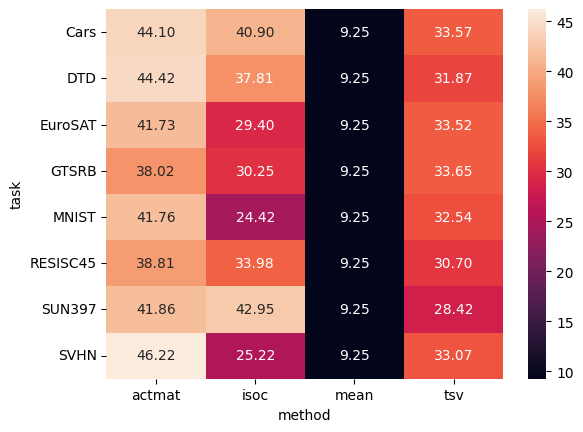

In [29]:
import seaborn as sns

task_cols = [c for c in df.columns if c.startswith("task")]
df[task_cols] = df[task_cols].div(df[task_cols].abs().sum(axis=1), axis=0)

long = df.melt(id_vars="method", var_name="task", value_name="alpha")
sns.heatmap(
    long.pivot_table(index="task", columns="method", values="alpha", aggfunc="sum"),
    annot=True,
    fmt=".2f",
    # cmap="RdBu_r",
    # center=0,
)